In [9]:
using Pkg
Pkg.activate("../")
using PyCall
using Roots
using Plots
using NLsolve
using Optim
using LaTeXStrings
using TimerOutputs

  Activating project at `~/Documents/Workshops/Surrogate/TwoVariableInter/3cpn_phasediag`


In [3]:
# CE free energy
F_c(ϕA, ϕB, αA, αB, χN) = ϕA*log(ϕA)/αA + ϕB*log(ϕB)/αB + χN*ϕA*ϕB
F_c(ϕ, α, χN) = F_c(ϕ, 1-ϕ, 1, α, χN)

dF_cdϕ(ϕA, ϕB, αA, αB, χN) = (1 + log(ϕA))/αA - (1 + log(1-ϕA))/αB + χN*(1-2ϕA)
dF_cdϕ(ϕ, α, χN) = dF_cdϕ(ϕ, 1, α, χN)

d2F_cdϕ2(ϕA, ϕB, αA, αB, χN) = 1/(αA*ϕA) + 1/(αB*(1-ϕA)) - 2χN
d2F_cdϕ2(ϕ, α, χN) = d2F_cdϕ2(ϕ, 1, α, χN)

γA(ϕA, ϕB, αA, αB, χN) = (1 + log(ϕA))/αA + χN*ϕB
γB(ϕA, ϕB, αA, αB, χN) = (1 + log(ϕB))/αB + χN*ϕA

μA(ϕA, ϕB, αA, αB, χN) = γA(ϕA, ϕB, αA, αB, χN) - γB(ϕA, ϕB, αA, αB, χN)
μA(ϕ, α, χN) = μA(ϕ, 1-ϕ, 1, α, χN)
μ(ϕ, α, χN) = μA(ϕ, α, χN)
μB(ϕA, ϕB, αA, αB, χN) = γB(ϕA, ϕB, αA, αB, χN) - γA(ϕA, ϕB, αA, αB, χN)
μB(ϕ, α, χN) = μB(ϕ, 1-ϕ, 1, α, χN)


# 功能：给定 μ、α、χN，求解满足 μA(ϕ)=μ 的 ϕ，并返回 ϕ 和对应的 F_c(ϕ)
function μ_to_ϕ(μ, α, χN, x=(0.001, 0.999))  # 区间避开0/1（避免log(0)报错）
    # 定义求根的目标函数：μA(ϕ) - μ = 0
    f(ϕ) = μA(ϕ, α, χN) - μ
    # 用二分法求解（Bisection））
    ϕ_sol = Roots.find_zero(f, x, Roots.Bisection())
    # 计算对应 ϕ 的自由能 F_c
    F_sol = F_c(ϕ_sol, α, χN)
    # 返回求解的ϕ和对应的自由能
    return ϕ_sol, F_sol
end

μ_to_ϕ (generic function with 2 methods)

In [7]:
α_test = 0.55
χN_test = 5.0
μ_test = -0.2

# 调用函数求解
ϕ_result, F_result = μ_to_ϕ(μ_test, α_test, χN_test)

# 输出结果
println("求解得到的 ϕ = ", ϕ_result)
println("对应自由能 F_c = ", F_result)
println("验证 μA(ϕ) = ", μA(ϕ_result, α_test, χN_test), " (应接近 μ_test = ", μ_test, ")")

求解得到的 ϕ = 0.014019698079967832
对应自由能 F_c = -0.016021249420734365
验证 μA(ϕ) = -0.20000000000000018 (应接近 μ_test = -0.2)


In [11]:
α_B = 0.5
χN = 5.0
ϕ_true = [0.019250479290657332, 0.9273968777165841]  # solved with Trust Region NLSolver

ϕ_list = [i for i in (0.001:0.001:0.999)]
Fc_FH = []
for ϕ in ϕ_list
    push!(Fc_FH, (F_c(ϕ, α_B, χN)))
end

In [ ]:
slope1 = μ(ϕ_true[1], α_B, χN)  # 相共存点导数相等，取任意一个即可
slope2 = μ(ϕ_true[2], α_B, χN)
is_coexist = (abs(slope1 - slope2) <= 1e-3)
if is_coexist
    f1 = F_c(ϕ_true[1], α_B, χN)
    f2 = F_c(ϕ_true[2], α_B, χN)
    intercept = f1 - slope1 * ϕ_true[1]
    tangent_x = [ϕ_true[1]-0.05, ϕ_true[2]+0.05]  # 切线范围略宽于两个相点
    tangent_y = slope1 .* tangent_x .+ intercept
end

2-element Vector{Float64}:
 -0.012681320552973562
 -0.08740404277692493

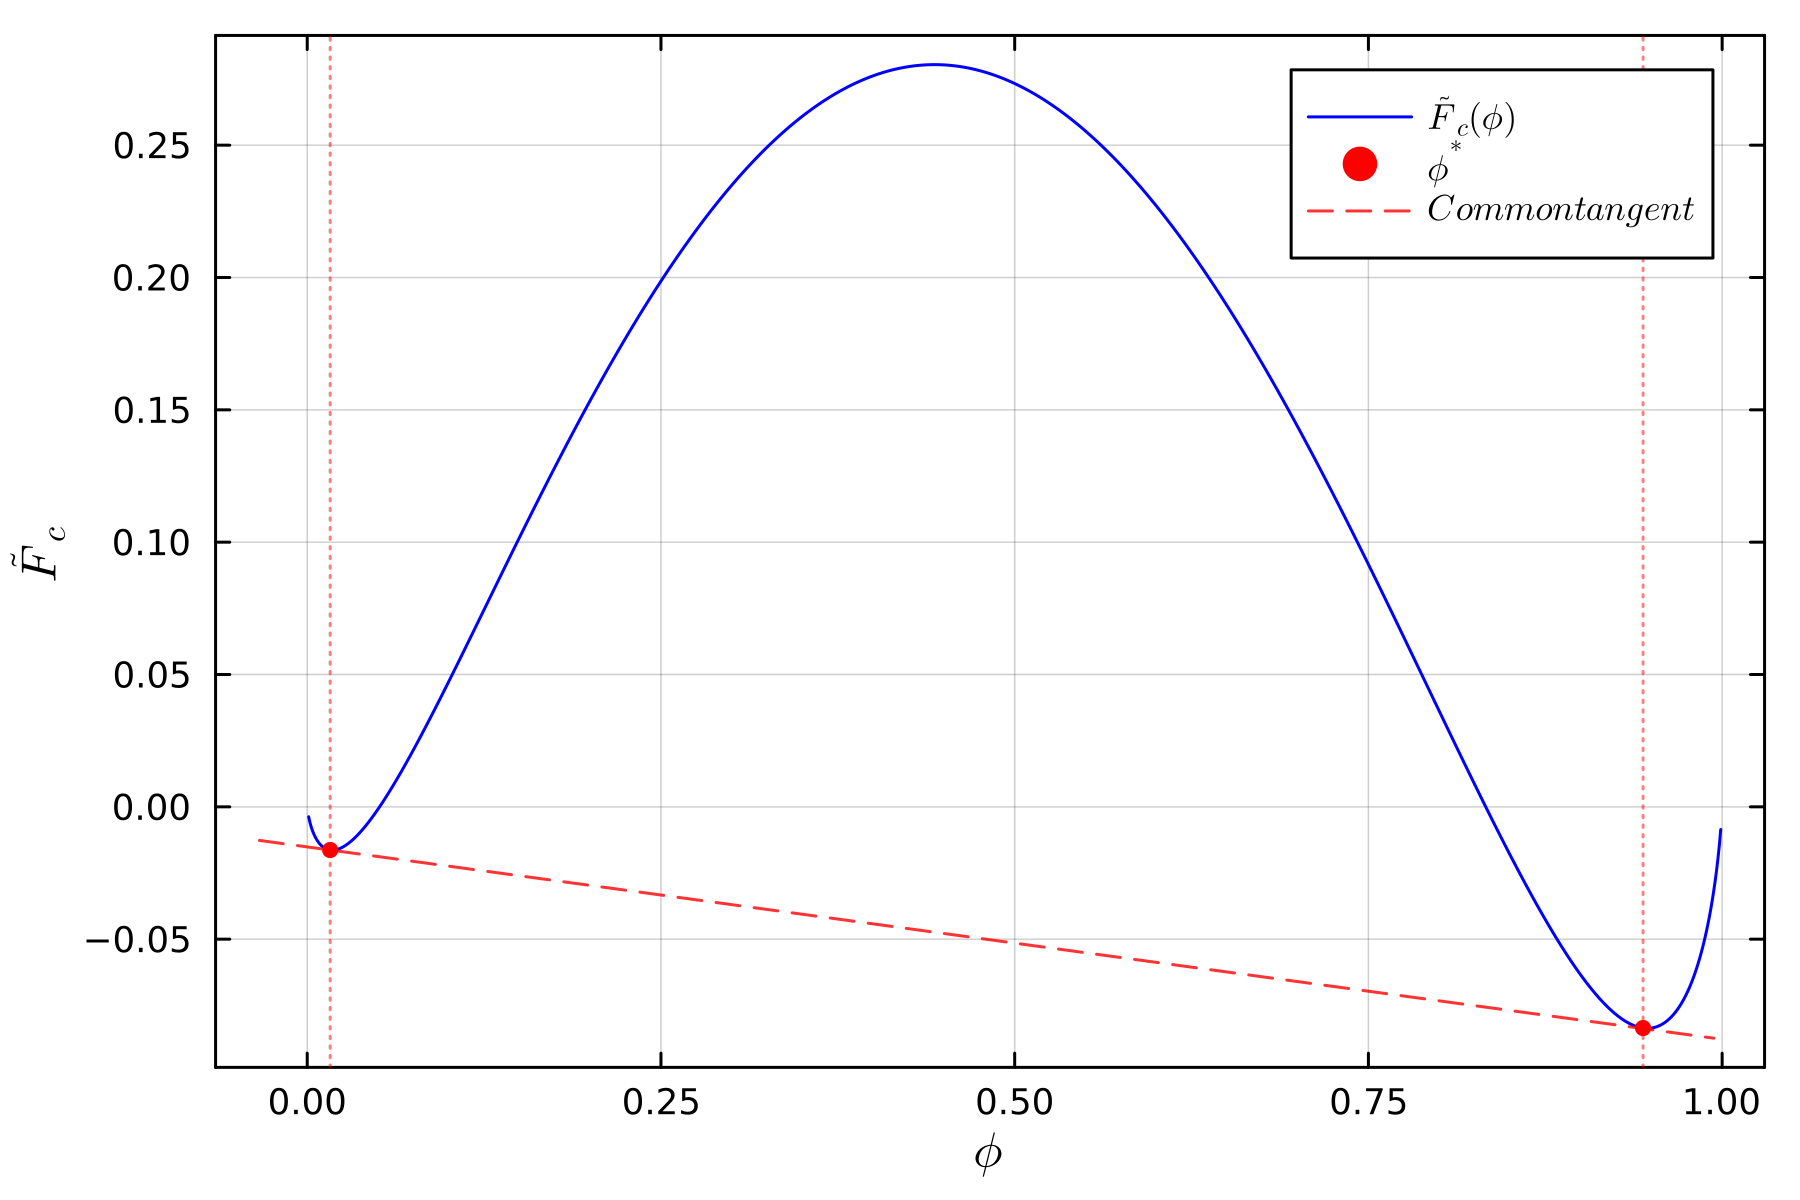

In [46]:
p = plot(
    ϕ_list, Fc_FH,
    xlabel=L"$\phi$",          # LaTeX标签
    ylabel=L"$\tilde{F}_c$",
    label=L"$\tilde{F}_c(\phi)$",  # 自由能曲线标签
    linewidth=1,               # 曲线宽度
    color=:blue,               # 曲线颜色
    legend=:topright,        # 图例位置
    framestyle=:box,           # 边框样式
    dpi=300                    # 分辨率
)

scatter!(
    p, ϕ_true, [f1, f2],
    label=L"$\phi^*$",  # 相共存点标签
    color=:red,
    markersize=3,               # 点大小
    markerstrokewidth=0,        # 取消点的边框
    marker=:circle              # 点形状
)

plot!(
    p, tangent_x, tangent_y,
    label=L"Common tangent",    # 公切线标签
    linestyle=:dash,            # 虚线
    linewidth=1,
    color=:red,
    alpha=0.8                   # 透明度
)

vline!(
    p, ϕ_true,
    label=false,                # 不显示图例
    linestyle=:dot,             # 点线
    color=:red,
    alpha=0.5
)

display(p)


# Surrogate Model Benchmark

## 1. Find coexitence point using conventional method
for CE system, one can find the coexistence point via solving the following two equations:
$$
\tilde{\mu}_{\alpha}(\phi_p^{\alpha}) = \tilde{\mu_{\beta}(\phi_p^{\beta})} = \mu
$$
$$
\tilde{F}^\alpha - \tilde{F}^\beta = \mu (\phi_p^\alpha - \phi_p^\beta)
$$

In [47]:
function CESolvers!(kb, TwoPhaseϕs, params) 
    ϕβ = TwoPhaseϕs[1]
    ϕα = TwoPhaseϕs[2]
    μα = μA(ϕα, params[1], params[2])
    μβ = μA(ϕβ, params[1], params[2])
    Fα = F_c(ϕα, params[1], params[2])
    Fβ = F_c(ϕβ, params[1], params[2])
    
    kb[1] = μα - μβ # 公切切线斜率 k 判据
    kb[2] = Fα - Fβ  - (ϕα - ϕβ)*μα  # 公切线截距 b 判据
end

CESolvers! (generic function with 1 method)

### 1.1. `nlsolve`, only need 2 initial points, but extremely sensitive:
- `trust_region`
- `newton`

In [ ]:
α_B = 0.5
χN = 5.0
params = [α_B,χN]
TwoPhaseϕs = [0.04, 0.9]


reset_timer!(to)
# args: method = :newton/:trust_region，xtol = 1e-10, store_trace = true
result = nlsolve((kb, TwoPhaseϕs) -> CESolvers!(kb, TwoPhaseϕs, params), TwoPhaseϕs,
                xtol=1e-8, show_trace = true, store_trace=true, method=:trust_region)

UndefVarError: UndefVarError: `to` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
exact_FH_calls = TimerOutputs.ncalls(to["CESolvers_Evaluation"] - 1 ) * 2 # first 2 points excluded, each time compute 2 new points

60

In [ ]:
FH_each_fcall = div(exact_FH_calls, (result.g_calls))

10

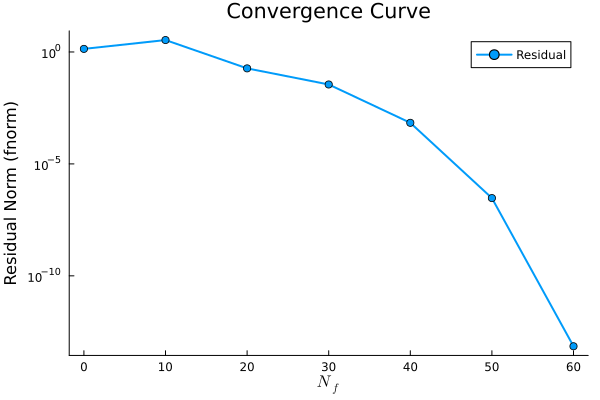

In [87]:
# 提取迭代步数
N_f = ([t.iteration for t in result.trace.states][1:result.g_calls] .+1 ).* FH_each_fcall
# 提取残差范数 (Function Norm)
residuals = [t.fnorm for t in result.trace.states][end-result.g_calls+1 : end]

# 添加初始点信息
pushfirst!(N_f, 0)
pushfirst!(residuals, result.trace.states[1].fnorm)

# 绘制带有对数坐标的残差收敛曲线
plot(N_f, residuals, 
    yscale = :log10,        # 开启对数坐标！
    marker = :circle,       # 圆点标记
    linewidth = 2,
    xlabel = raw"$N_{f}$",
    ylabel = "Residual Norm (fnorm)",
    title = "Convergence Curve",
    label = "Residual",
    grid = false,
    minorgrid = false
)

In [89]:
params = [α_B,χN]
TwoPhaseϕs = [0.04, 0.9]

reset_timer!(to)
# args: method = :newton/:trustregion，xtol = 1e-10, store_trace = true
result = nlsolve((kb, TwoPhaseϕs) -> CESolvers!(kb, TwoPhaseϕs, params), TwoPhaseϕs,
                xtol=1e-8, show_trace = false, store_trace=true, method=:newton)
show(to)

─────────────────────────────────────────────────────────────────────────────────
                                        Time                    Allocations      
                               ───────────────────────   ────────────────────────
       Tot / % measured:            155ms /   0.0%           12.8MiB /   0.0%    

Section                ncalls     time    %tot     avg     alloc    %tot      avg
─────────────────────────────────────────────────────────────────────────────────
CESolvers_Evaluation       40   2.83μs  100.0%  70.9ns     0.00B     - %    0.00B
─────────────────────────────────────────────────────────────────────────────────

In [92]:
result.trace

Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.374188e+00              NaN
     1     3.408660e+00     7.664056e-03
     2     1.359614e+00     3.618595e-04
     3     3.533967e-01     1.959393e-04
     4     4.055585e-02     2.356390e-05
     5     8.459973e-04     4.496105e-07
     6     4.465334e-07     2.355808e-10
     7     1.514344e-13     6.737130e-17


### 1.2 

In [26]:
using LinearAlgebra
using DataFrames
using CSV

const call_history = []
global f_call_counter = 0

function CESolvers!(kb, TwoPhaseϕs, params) 
    global f_call_counter += 2 # do SCFT / Flory Huggins calculation twice each call
    
    ϕβ = TwoPhaseϕs[1]
    ϕα = TwoPhaseϕs[2]
    
    μα = μA(ϕα, params[1], params[2])
    μβ = μA(ϕβ, params[1], params[2])
    Fα = F_c(ϕα, params[1], params[2])
    Fβ = F_c(ϕβ, params[1], params[2])
    
    kb[1] = μα - μβ 
    kb[2] = Fα - Fβ - (ϕα - ϕβ)*μα  
        
    # 计算与真值的误差（2-范数距离）
    global ϕ_true
    current_x = copy(TwoPhaseϕs)
    if isempty(call_history)
        step_size = norm(current_x - ϕ_true, 2) 
    else
        step_size = norm(current_x - ϕ_true, 2)
    end
    
    push!(call_history, (
        call_id = f_call_counter, 
        x = current_x, 
        step = step_size, 
        res = norm(kb, 2)
    ))
end

CESolvers! (generic function with 1 method)

In [27]:
# 参数初始化
α_B = 0.5
χN = 5.0
params = [α_B, χN]
TwoPhaseϕs = [0.04, 0.9]

empty!(call_history) # 运行前清空日志
global f_call_counter = 0

# 设定使用的算法名称
current_method = :trust_region

# 运行求解器
result = nlsolve((kb, TwoPhaseϕs) -> CESolvers!(kb, TwoPhaseϕs, params), TwoPhaseϕs,
                ftol=1e-16, show_trace = false, method=current_method)

fcalls_vec = [record.call_id for record in call_history]
step_vec = [record.step for record in call_history]

df = DataFrame(
    Algorithm = [string(current_method)],
    f_calls_vector = [string(fcalls_vec)],
    step_vector = [string(step_vec)]
)

csv_filename = "solver_history_vectors.csv"
CSV.write(csv_filename, df, append=isfile(csv_filename)) 

println("数据已成功保存至单行向量格式: ", csv_filename)

数据已成功保存至单行向量格式: solver_history_vectors.csv


In [35]:
# 参数初始化
α_B = 0.5
χN = 5.0
params = [α_B, χN]
TwoPhaseϕs = [0.04, 0.9]

empty!(call_history) # 运行前清空日志
global f_call_counter = 0

# 设定使用的算法名称
current_method = :newton

# 运行求解器
result = nlsolve((kb, TwoPhaseϕs) -> CESolvers!(kb, TwoPhaseϕs, params), TwoPhaseϕs,
                ftol=1e-16, show_trace = false, method=current_method)

fcalls_vec = [record.call_id for record in call_history]
step_vec = [record.step for record in call_history]

df = DataFrame(
    Algorithm = [string(current_method)],
    f_calls_vector = [string(fcalls_vec)],
    step_vector = [string(step_vec)]
)

csv_filename = "solver_history_vectors.csv"
CSV.write(csv_filename, df, append=isfile(csv_filename)) 

println("数据已成功保存至单行向量格式: ", csv_filename)

数据已成功保存至单行向量格式: solver_history_vectors.csv


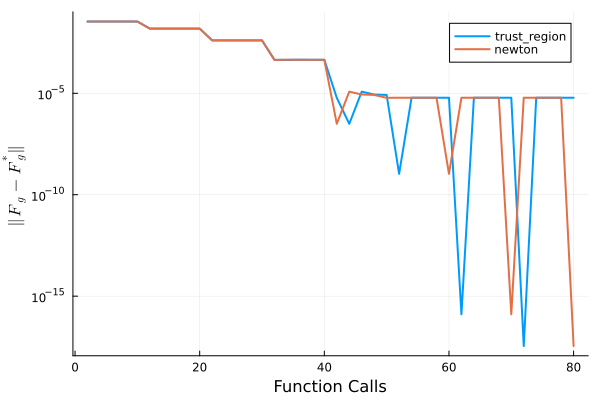

UndefVarError: UndefVarError: `save` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:
# 1. 读取 CSV 文件数据
df = CSV.read("./solver_history_vectors.csv", DataFrame)

# 2. 定义辅助函数：用于将 "[1.0, 2.0, 3.0]" 这样的字符串转换为真正的 Float64 数组
function parse_array_string(s::String)
    clean_str = strip(s, ['[', ']']) # 移除首尾的中括号
    if isempty(clean_str)
        return Float64[]
    end
    return parse.(Float64, split(clean_str, ","))
end

# 3. 初始化空白画布并设置标题、坐标轴标签，以及将 Y 轴设置为对数坐标
p = plot(xlabel="Function Calls", ylabel=L"$∥F_{g} - F_{g}^{*}∥$", yscale=:log10)

# 4. 遍历 CSV 中的每一行（每行代表一种 Algorithm），各自绘制折线图
for row in eachrow(df)
    alg_name = row.Algorithm
    f_calls = parse_array_string(row.f_calls_vector)
    steps = parse_array_string(row.step_vector)
    
    # 移除 marker 设置，仅绘制折线
    plot!(p, f_calls[1:40], steps[1:40], label=alg_name, lw=2)
end

# 5. 显示并渲染最终图表
display(p)
# save 
save(p)
